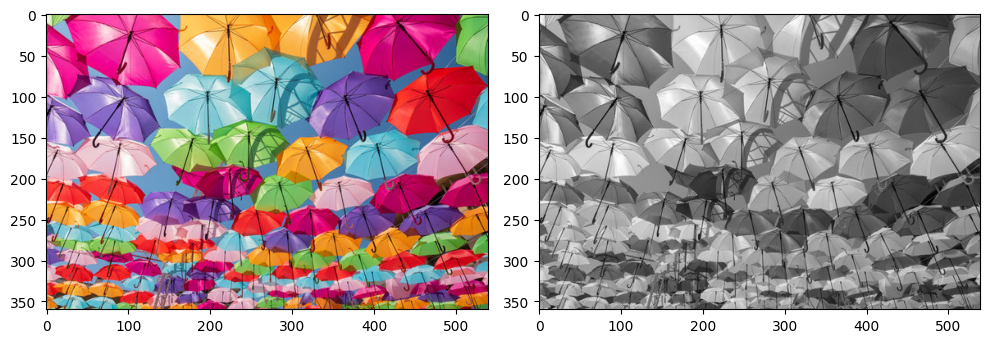

In [33]:
import cv2
import matplotlib.pyplot as plt

I = cv2.imread("img.jpg")
gray = cv2.cvtColor(I, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(I, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray')

plt.tight_layout()
plt.show()

In [34]:
gray_new = gray[:3, :3]
print(gray_new)

[[249 248 241]
 [247 247 242]
 [246 247 243]]


In [ ]:
import numpy as np

padded = np.pad(gray_new, pad_width=1, mode='constant', constant_values=0)
print("Original 3x3 matrix:")
print(gray_new)
print("\nPadded 5x5 matrix:")
print(padded)

Original 3x3 matrix:
[[249 248 241]
 [247 247 242]
 [246 247 243]]

Padded 5x5 matrix:
[[  0   0   0   0   0]
 [  0 249 248 241   0]
 [  0 247 247 242   0]
 [  0 246 247 243   0]
 [  0   0   0   0   0]]


In [38]:
Sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

Sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

print("Sobel X matrix:")
print(Sobel_x)
print("Sobel Y matrix:")
print(Sobel_y)


Sobel X matrix:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
Sobel Y matrix:
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]


In [ ]:
kernel_size = 3
output_size = padded.shape[0] - kernel_size + 1

conv_x = np.zeros((output_size, output_size))
conv_y = np.zeros((output_size, output_size))

for i in range(output_size):
    for j in range(output_size):
        region = padded[i:i+kernel_size, j:j+kernel_size]
        
        conv_x[i, j] = np.sum(region * Sobel_x)
        
        conv_y[i, j] = np.sum(region * Sobel_y)

print("Convolution result with Sobel X:")
print(conv_x.astype(int))
print("\nConvolution result with Sobel Y:")
print(conv_y.astype(int))

gradient_magnitude = np.sqrt(conv_x**2 + conv_y**2)
print("\nGradient Magnitude:")
print(gradient_magnitude.astype(int))

Convolution result with Sobel X:
[[ 743  -21 -743]
 [ 989  -21 -989]
 [ 741  -11 -741]]

Convolution result with Sobel Y:
[[ 741  983  731]
 [  -7   -3    3]
 [-741 -983 -731]]

Gradient Magnitude:
[[1049  983 1042]
 [ 989   21  989]
 [1047  983 1040]]
